# Train BERT model with regression for price prediction based on AirBnB descriptions

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy
import sklearn
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#import torch
torch.cuda.empty_cache()
torch.cuda.ipc_collect()


# Data Preparation

In [3]:
reviews = pd.read_csv("Data/reviews_priced.csv")  # venice listings
reviews = reviews[~reviews["price"].isna()]


In [4]:
# Complete text-cleaning function for BERT
import re
import html
import unicodedata

def text_cleaning(text):
     # Normalize unicode chars
    text = unicodedata.normalize("NFKC", text)

    # Unescape HTML entities 
    text = html.unescape(text)

    # Replace non-breaking spaces and weird unicode chars
    text = text.replace(u'\xa0', ' ').replace(u'\u200b', '')

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.replace(u'\xa0', u' ') # Replace non-breaking space with normal space
    return text

In [5]:
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,price
0,6624,581824,2011-09-29,1189528,Lawrence,The apartment was wonderful and despite our de...,227.0
1,6624,654634,2011-10-23,71925,Helen & Rob,This is truly the best place to be. A very nic...,227.0
2,6624,2774855,2012-11-01,1570645,Linda,This was a great location and such wonderful p...,227.0
3,6624,2987711,2012-11-28,4041941,Joseph,Your apartment gave us a home in Venice...maki...,227.0
4,6624,5385172,2013-06-27,743472,Steve And Serenella,"Very nicely and tastefully furnished, clean ...",227.0


In [6]:
type(reviews['comments'][0])

str

In [7]:
# Cleaning of descriptions column
reviews = reviews.copy()
reviews.loc[:, 'clean_review'] = reviews.comments.fillna('').apply(text_cleaning)


In [8]:

# Preparing dfs for training + validation and testing
split_ids = int(reviews.shape[0] * 0.8)
reviews_df = reviews.iloc[:split_ids, :].reset_index(drop=True)
reviews_df_test = reviews.iloc[split_ids:, :].reset_index(drop=True)


# Tokenization

In [9]:
# Tokenization
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-multilingual-cased")


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

In [10]:
encoded_corpus = tokenizer(text=reviews_df.clean_review.tolist(),
                        add_special_tokens=True,
                        padding='max_length',
                        truncation='longest_first',
                        max_length=512,
                        return_attention_mask=True)

input_ids = encoded_corpus['input_ids']
attention_mask = encoded_corpus['attention_mask']

# Input data preparation

In [11]:

# Review indicies
reviews_ids = np.arange(len(reviews_df))

input_ids = np.array(input_ids)[reviews_ids]
attention_mask = np.array(attention_mask)[reviews_ids]

# Log transform price column
labels = np.log1p(reviews_df['price'].to_numpy())


In [12]:
test_size = 0.2
seed = 42
train_inputs, val_inputs, train_labels, val_labels = \
            train_test_split(input_ids, labels, test_size=test_size,
                             random_state=seed)
train_masks, val_masks, _, _ = train_test_split(attention_mask,
                                        labels, test_size=test_size,
                                        random_state=seed)

In [13]:
# Normalize the data
from sklearn.preprocessing import StandardScaler
price_scaler = StandardScaler()
price_scaler.fit(val_labels.reshape(-1, 1))
train_labels = price_scaler.transform(train_labels.reshape(-1, 1))
val_labels = price_scaler.transform(val_labels.reshape(-1, 1))

In [14]:
# Prepare dataloaders for training and validation
from torch.utils.data import TensorDataset, DataLoader
batch_size = 64
def create_dataloaders(inputs, masks, labels, batch_size):
    input_tensor = torch.tensor(inputs)
    mask_tensor = torch.tensor(masks)
    labels_tensor = torch.tensor(labels)
    dataset = TensorDataset(input_tensor, mask_tensor,
                            labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            shuffle=True)
    return dataloader
train_dataloader = create_dataloaders(train_inputs, train_masks,
                                      train_labels, batch_size)
val_dataloader = create_dataloaders(val_inputs, val_masks,
                                     val_labels, batch_size)

In [15]:
# Test dataset prepration
test_encoded = tokenizer(
    text=reviews_df_test["clean_review"].tolist(),
    add_special_tokens=True,
    padding='max_length',
    truncation='longest_first',
    max_length=512,
    return_attention_mask=True
)
test_input_ids = np.array(test_encoded['input_ids'])
test_attention_mask = np.array(test_encoded['attention_mask'])
test_labels = np.log1p(reviews_df_test["price"].to_numpy())
test_labels = price_scaler.transform(test_labels.reshape(-1, 1))

test_dataloader = create_dataloaders(test_input_ids, test_attention_mask, test_labels, batch_size=batch_size)


# Model Definition and Training

In [16]:
# BERT model class definition
from transformers import DistilBertModel

class BertRegressor(nn.Module):
    def __init__(self, drop_rate=0.1, freeze_bert_layers=True, n_unfrozen_layers=2):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-multilingual-cased")

        if freeze_bert_layers:
            # Freeze all layers first
            for param in self.bert.parameters():
                param.requires_grad = False

            # Unfreeze last `n_unfrozen_layers` transformer blocks
            for layer in self.bert.transformer.layer[-n_unfrozen_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True

        self.regressor = nn.Sequential(
            nn.Dropout(drop_rate),
            nn.Linear(self.bert.config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(drop_rate),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0]  # CLS token
        return self.regressor(cls_embedding)

2025-07-13 19:33:47.883895: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752435228.095110      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752435228.154233      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [17]:
# Define a model to train
model = BertRegressor(drop_rate=0.3, freeze_bert_layers=True, n_unfrozen_layers=2)

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

In [18]:
# Check availability of GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU.")
else:
    print("No GPU available, using the CPU instead.")
    device = torch.device("cpu")
model.to(device)

Using GPU.


BertRegressor(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(

In [19]:

optimizer = torch.optim.AdamW(model.parameters(),
                  lr=1e-4,
                  weight_decay=0.1)


In [20]:
from transformers import get_linear_schedule_with_warmup
epochs = 10
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer,
                 num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

In [21]:
loss_function = nn.MSELoss()

In [22]:
# Validation function
def evaluate(model, loss_function, test_dataloader, device):
    model.eval()

    test_loss, test_r2 = 0, 0
    for batch in test_dataloader:
        batch_inputs, batch_masks, batch_labels = \
                                 tuple(b.to(device) for b in batch)
        with torch.no_grad():
            outputs = model(batch_inputs, batch_masks)
        loss = loss_function(outputs, batch_labels)

        test_loss += loss.item()
        r2 = r2_score(outputs, batch_labels)
        test_r2 += r2.item()
    return test_loss, test_r2
def r2_score(outputs, labels):
    labels_mean = torch.mean(labels)
    ss_tot = torch.sum((labels - labels_mean) ** 2)
    ss_res = torch.sum((labels - outputs) ** 2)
    r2 = 1 - ss_res / ss_tot
    return r2


In [23]:
# Plot losses for each epoch for training and validation
def plot_losses_epochs(n_epoch,train_losses, val_losses):
    # n_epoch of type int
    # train_losses of type list
    # val_losses of type list
    epochs = [e+1 for e in range(n_epoch)]

    # Create DataFrame for Seaborn
    loss_df = pd.DataFrame({
        'Epoch': epochs * 2,
        'Loss': train_losses + val_losses,
        'Set': ['Training results'] * len(epochs) + ['Validation results'] * len(epochs)
    })

    # Plot
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=loss_df,
        x='Epoch',
        y='Loss',
        hue='Set',
        style='Set',
        markers=True,
        dashes=True
    )
    plt.title("Epoch vs. Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xlim(1, len(epochs))
    plt.show()


In [25]:
# Training function including validation
from torch.nn.utils.clip_grad import clip_grad_norm_

from torch.amp import autocast, GradScaler
scaler = GradScaler(device='cuda')

def train(model, optimizer, scheduler, loss_function, epochs,
          train_dataloader, device, test_dataloader, clip_value=2):

    train_loss = []
    test_loss, test_r2 = [], []

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        model.train()
        loss_epoch = 0

        for step, batch in enumerate(train_dataloader):
            batch_inputs, batch_masks, batch_labels = \
                tuple(b.to(device) for b in batch)

            optimizer.zero_grad()
            batch_labels = batch_labels.to(torch.float32)
            
            with autocast(device_type='cuda'):  # Mixed precision
                outputs = model(batch_inputs, batch_masks)
                outputs = outputs.to(torch.float32)
                loss = loss_function(outputs.squeeze(), batch_labels.squeeze())
            
            
            loss =loss.float()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            clip_grad_norm_(model.parameters(), clip_value)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            
            loss_epoch += loss.item()

            if step % 100 == 0:
                print(f"  Step {step}: loss = {loss.item():.4f}")

        avg_train_loss = loss_epoch / len(train_dataloader)
        train_loss.append(avg_train_loss)
        print(f"Average training loss: {avg_train_loss:.4f}")

        # Evaluation
        test_loss_epoch, test_r2_epoch = evaluate(model, loss_function, test_dataloader, device)
        test_loss.append(test_loss_epoch)
        test_r2.append(test_r2_epoch)

    return model, train_loss, test_loss, test_r2
model, train_loss, val_loss, val_r2 = train(model, optimizer, scheduler, loss_function, epochs,
              train_dataloader, device, val_dataloader, clip_value=2)

Epoch 1/10
  Step 0: loss = 1.4548
  Step 100: loss = 0.9162
  Step 200: loss = 1.0151
  Step 300: loss = 0.9335
  Step 400: loss = 1.1320
  Step 500: loss = 0.8398
  Step 600: loss = 1.0622
  Step 700: loss = 1.1491
  Step 800: loss = 1.1901
  Step 900: loss = 0.9173
  Step 1000: loss = 0.8488
  Step 1100: loss = 0.7152
  Step 1200: loss = 0.8110
  Step 1300: loss = 1.4322
  Step 1400: loss = 0.7290
  Step 1500: loss = 0.5422
  Step 1600: loss = 1.0548
  Step 1700: loss = 0.8275
  Step 1800: loss = 0.4853
  Step 1900: loss = 0.7852
  Step 2000: loss = 0.5873
  Step 2100: loss = 0.8405
  Step 2200: loss = 0.6739
  Step 2300: loss = 0.4773
  Step 2400: loss = 0.5934
  Step 2500: loss = 0.7365
  Step 2600: loss = 1.0792
  Step 2700: loss = 0.8012
  Step 2800: loss = 0.6879
  Step 2900: loss = 0.7395
  Step 3000: loss = 0.5508
  Step 3100: loss = 0.7156
  Step 3200: loss = 0.7510
  Step 3300: loss = 0.7707
  Step 3400: loss = 0.8622
  Step 3500: loss = 0.7094
  Step 3600: loss = 0.4588
  

In [26]:
# Export the trained model
import pickle

model_reviews = "reviews_model.pkl" 
with open(model_reviews, "wb") as f:
    pickle.dump(model, f)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


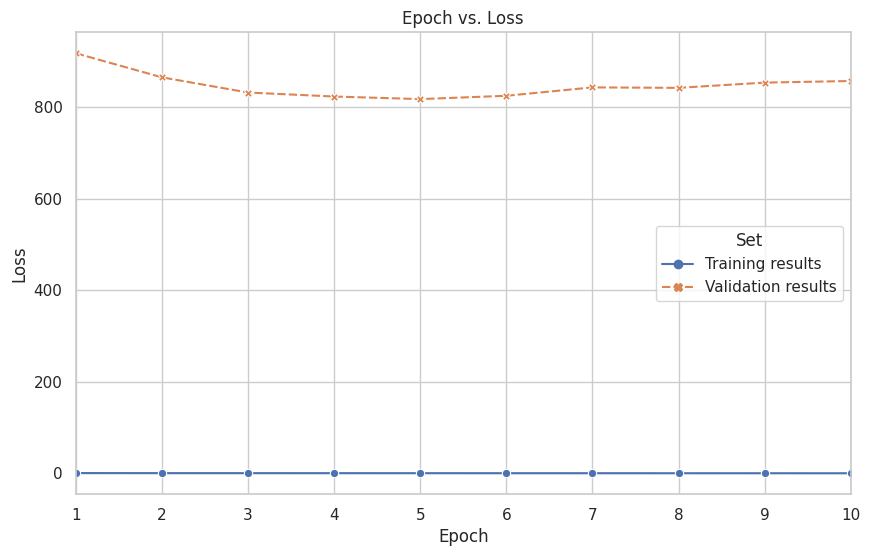

In [27]:
plot_losses_epochs(epochs,train_loss, val_loss)